# PyQuil Error Mitigation — Reusable Workflow (July 6–10)

This notebook continues the error-mitigation study from the July 1–5 notebook. Where the earlier notebook walked through the ideas step by step, this one turns them into **reusable functions** and then uses those functions to test how well Zero-Noise Extrapolation (ZNE) actually works.

The plan follows the daily C-DAC research tasks for the week:

| Day | Focus | What gets built |
|---|---|---|
| Jul 6 | Reusable core | `counts_to_expectation` and a `run_circuit` function that returns $\langle ZZ \rangle$ |
| Jul 7 | Readout mitigation | A reusable mitigation function, tested on a 2-qubit noisy simulator |
| Jul 8 | ZNE folding | A folding function, automatic scale factors 1, 3, 5, and an equivalence check |
| Jul 9 | Extrapolation | A linear-extrapolation function, a noise-scale plot, and a saved ZNE estimate |
| Jul 10 | Robustness | A sweep over noise strengths to see when ZNE helps and when it breaks |

As before, PyQuil builds the circuits and computes their ideal unitaries, while NumPy handles the sampling, the confusion-matrix algebra, and the straight-line fit. The noise is modelled analytically (a symmetric bit-flip channel), so the whole notebook runs without any external QVM service.

## Setup: Imports and Constants

This cell loads the libraries and fixes the constants that the rest of the notebook reuses.

- `SHOTS` is how many measurements are simulated per circuit.
- `READOUT_ERROR` ($e$) is the probability that a measured bit is reported incorrectly.
- `CNOT_GATE_ERROR` is the extra bit-flip noise attached to each CNOT gate, used to give ZNE something to extrapolate.
- For $\langle ZZ \rangle$, outcomes `00` and `11` count as $+1$ (qubits agree) and `01`, `10` count as $-1$ (qubits disagree).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pyquil import Program
from pyquil.gates import CNOT, H
from pyquil.simulation.tools import program_unitary


BITSTRINGS = ["00", "01", "10", "11"]
SHOTS = 8192
SEED = 7

READOUT_ERROR = 0.08
CNOT_GATE_ERROR = 0.02

np.set_printoptions(precision=4, suppress=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#D5DAE0",
    "axes.labelcolor": "#263238",
    "xtick.color": "#37474F",
    "ytick.color": "#37474F",
    "text.color": "#263238",
    "font.size": 10,
})

# One dictionary collects the numbers worth keeping as the notebook runs.
results = {}

## Jul 6 — Reusable Core Functions

The first task is to take the Bell experiment from last week and package it as small functions that later cells can call directly, instead of repeating the same code.

Three pieces are defined here:

- `state_probabilities` computes the ideal outcome probabilities of a circuit from its unitary.
- `counts_to_expectation` turns a histogram of measured counts into the expectation value

$$
\langle ZZ \rangle = \frac{N_{00} + N_{11} - N_{01} - N_{10}}{N_{\text{shots}}}
$$

- `run_circuit` ties everything together: it takes a circuit (and an optional noise model), simulates measurements, and returns $\langle ZZ \rangle$.

`bell_program(cnot_count)` builds the standard Bell circuit, but allows repeated CNOTs so the same function can be reused for the folding step on Jul 8.

In [2]:
def bell_program(cnot_count=1):
    program = Program(H(0))
    for _ in range(cnot_count):
        program += CNOT(0, 1)
    return program


def state_probabilities(program):
    unitary = program_unitary(program, n_qubits=2)
    initial_state = np.array([1, 0, 0, 0], dtype=complex)
    state = unitary @ initial_state
    probabilities = np.abs(state) ** 2
    return {bitstring: float(prob) for bitstring, prob in zip(BITSTRINGS, probabilities)}


def sample_counts(probabilities, shots=SHOTS, seed=SEED):
    rng = np.random.default_rng(seed)
    probs = np.array([probabilities.get(bitstring, 0.0) for bitstring in BITSTRINGS])
    samples = rng.multinomial(shots, probs / probs.sum())
    return dict(zip(BITSTRINGS, samples.tolist()))


def counts_to_expectation(counts):
    shots = sum(counts.values())
    same = counts.get("00", 0) + counts.get("11", 0)
    different = counts.get("01", 0) + counts.get("10", 0)
    return (same - different) / shots


def run_circuit(program, noise=None, shots=SHOTS, seed=SEED):
    probabilities = state_probabilities(program)
    if noise is not None:
        probabilities = noise(probabilities)
    counts = sample_counts(probabilities, shots=shots, seed=seed)
    return counts_to_expectation(counts)

### Check: ideal Bell circuit

Running the reusable `run_circuit` on a clean Bell circuit should return a value very close to the ideal $\langle ZZ \rangle = 1$, with only tiny sampling jitter.

In [3]:
bell = bell_program(cnot_count=1)
ideal_zz = run_circuit(bell)

results["ideal_zz"] = ideal_zz

print("Bell circuit:")
print(bell)
print("Ideal <ZZ> from run_circuit:", round(ideal_zz, 6))

Bell circuit:
H 0
CNOT 0 1

Ideal <ZZ> from run_circuit: 1.0


## Jul 7 — Readout Mitigation as a Reusable Function

The second task packages readout-error correction as functions and tests them on the noisy simulator.

Readout noise is modelled as an independent bit-flip on each qubit with probability $e$. For two qubits this gives the confusion matrix

$$
M = K \otimes K, \qquad K = \begin{pmatrix} 1 - e & e \\ e & 1 - e \end{pmatrix}
$$

- `apply_readout_noise` multiplies the ideal probabilities by $M$ to produce the observed (noisy) distribution.
- `mitigate_counts` inverts the process, solving $M\mathbf{x} = \mathbf{y}$ for the corrected distribution, then clipping and renormalizing it to stay a valid probability vector.

The test below runs the Bell circuit through readout noise, records the raw noisy $\langle ZZ \rangle$, applies mitigation, and records the corrected value — saving both so the improvement is easy to compare.

In [4]:
def readout_probability(observed, true, error):
    probability = 1.0
    for observed_bit, true_bit in zip(observed, true):
        probability *= (1 - error) if observed_bit == true_bit else error
    return probability


def confusion_matrix(error):
    return np.array([
        [readout_probability(observed, true, error) for true in BITSTRINGS]
        for observed in BITSTRINGS
    ])


def apply_readout_noise(probabilities, error=READOUT_ERROR):
    vector = np.array([probabilities.get(bitstring, 0.0) for bitstring in BITSTRINGS])
    noisy_vector = confusion_matrix(error) @ vector
    return {bitstring: float(prob) for bitstring, prob in zip(BITSTRINGS, noisy_vector)}


def expectation_from_probabilities(probabilities):
    same = probabilities.get("00", 0.0) + probabilities.get("11", 0.0)
    different = probabilities.get("01", 0.0) + probabilities.get("10", 0.0)
    return same - different


def mitigate_counts(counts, error=READOUT_ERROR):
    shots = sum(counts.values())
    observed = np.array([counts.get(bitstring, 0) / shots for bitstring in BITSTRINGS])
    mitigated = np.linalg.solve(confusion_matrix(error), observed)

    mitigated = np.clip(mitigated, 0.0, 1.0)
    mitigated = mitigated / mitigated.sum()

    return {bitstring: float(prob) for bitstring, prob in zip(BITSTRINGS, mitigated)}

In [5]:
# Test on the 2-qubit noisy simulator: prepare noisy counts from the Bell circuit.
ideal_probabilities = state_probabilities(bell)
noisy_probabilities = apply_readout_noise(ideal_probabilities, READOUT_ERROR)
noisy_counts = sample_counts(noisy_probabilities, seed=SEED)

# Before mitigation.
raw_noisy_zz = counts_to_expectation(noisy_counts)

# After mitigation.
mitigated_probabilities = mitigate_counts(noisy_counts, READOUT_ERROR)
mitigated_zz = expectation_from_probabilities(mitigated_probabilities)

# Save before/after results.
results["readout_raw_zz"] = raw_noisy_zz
results["readout_mitigated_zz"] = mitigated_zz

print("Noisy counts:", noisy_counts)
print("Before mitigation  <ZZ>:", round(raw_noisy_zz, 6))
print("After  mitigation  <ZZ>:", round(mitigated_zz, 6))
print("Ideal target       <ZZ>:", round(results["ideal_zz"], 6))

Noisy counts: {'00': 3487, '01': 584, '10': 585, '11': 3536}
Before mitigation  <ZZ>: 0.7146
After  mitigation  <ZZ>: 1.0
Ideal target       <ZZ>: 1.0


### Visual: before vs after readout mitigation

The chart compares $\langle ZZ \rangle$ before and after mitigation against the ideal target of $1$. Mitigation should move the noisy value back up toward the dashed line.

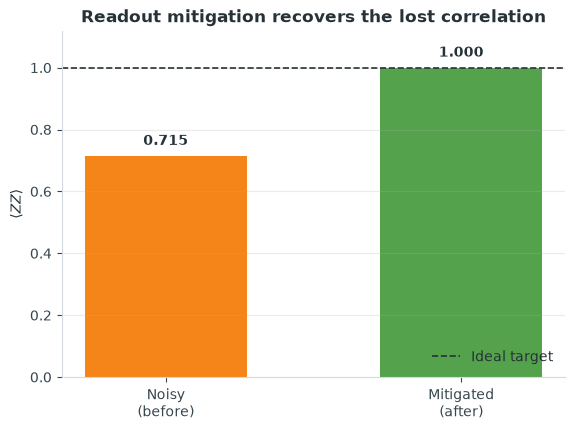

In [6]:
labels = ["Noisy\n(before)", "Mitigated\n(after)"]
values = [raw_noisy_zz, mitigated_zz]
colors = ["#F58518", "#54A24B"]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(labels, values, color=colors, width=0.55)
ax.axhline(results["ideal_zz"], color="#263238", linestyle="--", linewidth=1.2, label="Ideal target")
ax.set_ylim(0, 1.12)
ax.set_ylabel(r"$\langle ZZ \rangle$")
ax.set_title("Readout mitigation recovers the lost correlation", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, loc="lower right")

for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.025, f"{value:.3f}", ha="center", va="bottom", weight="bold")

plt.show()

## Jul 8 — CNOT Folding Function

The third task builds the noise-scaling step needed for ZNE.

**Folding** replaces one CNOT with an odd number of CNOTs. Because a CNOT is its own inverse, an odd number of them acts like a single CNOT in the ideal (noiseless) case:

$$
\mathrm{CNOT}^{2k+1} = \mathrm{CNOT}
$$

So the *logical* circuit is unchanged, but a real noisy device runs more gates and therefore accumulates more error — exactly the controlled increase in noise that ZNE needs.

Three helpers are defined:

- `fold_cnots` builds the Bell circuit with a given odd CNOT count.
- `generate_scale_factors` produces the odd scale factors `1, 3, 5, …` automatically.
- `verify_folding_equivalence` confirms each folded circuit has the same unitary as the original, so folding really is logically equivalent.

In [7]:
def fold_cnots(scale):
    if scale % 2 == 0:
        raise ValueError("Scale factor must be odd so that CNOT^scale == CNOT.")
    return bell_program(cnot_count=scale)


def generate_scale_factors(count=3):
    return [2 * k + 1 for k in range(count)]


def verify_folding_equivalence(scale_factors):
    base_unitary = program_unitary(fold_cnots(1), n_qubits=2)
    rows = []
    for scale in scale_factors:
        folded_unitary = program_unitary(fold_cnots(scale), n_qubits=2)
        is_equivalent = np.allclose(folded_unitary, base_unitary, atol=1e-10)
        rows.append((scale, is_equivalent))
    return rows


scale_factors = generate_scale_factors(count=3)
equivalence = verify_folding_equivalence(scale_factors)

print("Automatic scale factors:", scale_factors)
print()
print("Scale | CNOTs | Unitary equals the unfolded circuit?")
print("------+-------+--------------------------------------")
for scale, is_equivalent in equivalence:
    print(f"  {scale}   |   {scale}   | {is_equivalent}")

results["scale_factors"] = scale_factors
results["folding_all_equivalent"] = all(is_equivalent for _, is_equivalent in equivalence)

Automatic scale factors: [1, 3, 5]

Scale | CNOTs | Unitary equals the unfolded circuit?
------+-------+--------------------------------------
  1   |   1   | True
  3   |   3   | True
  5   |   5   | True


## Jul 9 — Linear Extrapolation

The fourth task adds the extrapolation itself.

Each folded circuit runs at scale $s \in \{1, 3, 5\}$ with gate noise that grows with the number of CNOTs, producing a noisy $\langle ZZ \rangle(s)$. Fitting a straight line

$$
\langle ZZ \rangle(s) = m\,s + b
$$

and reading off the intercept gives the zero-noise estimate:

$$
\langle ZZ \rangle_{\text{ZNE}} = b = \langle ZZ \rangle(0)
$$

- `gate_noise` applies the per-CNOT bit-flip channel once for each CNOT in the folded circuit.
- `linear_extrapolation` fits the line and returns the slope, intercept, and the intercept as the estimate.

The estimate and its distance from the ideal value are saved for the final comparison.

In [8]:
def gate_noise(probabilities, cnot_count, error=CNOT_GATE_ERROR):
    noisy = probabilities
    for _ in range(cnot_count):
        noisy = apply_readout_noise(noisy, error)
    return noisy


def linear_extrapolation(scale_factors, values):
    slope, intercept = np.polyfit(scale_factors, values, deg=1)
    return float(slope), float(intercept)


scaled_values = []
for scale in scale_factors:
    folded = fold_cnots(scale)
    zz = run_circuit(
        folded,
        noise=lambda p, s=scale: gate_noise(p, cnot_count=s, error=CNOT_GATE_ERROR),
        seed=SEED + scale,
    )
    scaled_values.append(zz)

slope, intercept = linear_extrapolation(scale_factors, scaled_values)
zne_estimate = intercept
zne_error = abs(results["ideal_zz"] - zne_estimate)

results["zne_estimate"] = zne_estimate
results["zne_error_from_ideal"] = zne_error

print("Scale factors:", scale_factors)
print("Noisy <ZZ> at each scale:", [round(v, 6) for v in scaled_values])
print("Linear fit: <ZZ>(s) =", round(slope, 6), "* s +", round(intercept, 6))
print("ZNE zero-noise estimate:", round(zne_estimate, 6))
print("Error from ideal:", round(zne_error, 6))

Scale factors: [1, 3, 5]
Noisy <ZZ> at each scale: [0.918213, 0.77002, 0.656982]
Linear fit: <ZZ>(s) = -0.065308 * s + 0.977661
ZNE zero-noise estimate: 0.977661
Error from ideal: 0.022339


### Visual: noise scale vs expectation value

The measured points sit at scales `1, 3, 5`. The dashed line is the linear fit, and the highlighted point at scale `0` is the extrapolated zero-noise estimate.

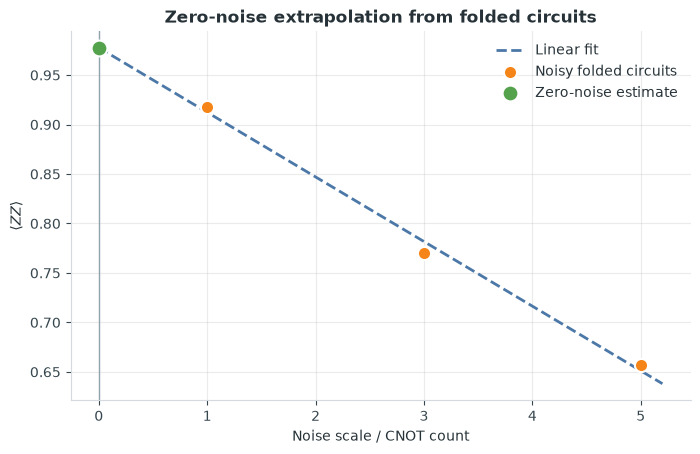

In [9]:
fit_x = np.linspace(0, max(scale_factors) + 0.2, 100)
fit_y = slope * fit_x + intercept

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(fit_x, fit_y, linestyle="--", color="#4C78A8", linewidth=2, label="Linear fit")
ax.scatter(scale_factors, scaled_values, s=90, color="#F58518", edgecolor="white",
           linewidth=1.5, label="Noisy folded circuits", zorder=3)
ax.scatter([0], [zne_estimate], s=130, color="#54A24B", edgecolor="white",
           linewidth=1.5, label="Zero-noise estimate", zorder=4)
ax.axvline(0, color="#90A4AE", linewidth=1)
ax.set_xlabel("Noise scale / CNOT count")
ax.set_ylabel(r"$\langle ZZ \rangle$")
ax.set_title("Zero-noise extrapolation from folded circuits", weight="bold")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.25)
plt.show()

## Jul 10 — Testing ZNE Across Noise Strengths

The final task stress-tests ZNE: when does it help, and when does it break? There are two separate failure modes, and the notebook checks both.

**1. Systematic bias (a modelling limit).** For this bit-flip channel the true expectation decays roughly as

$$
\langle ZZ \rangle(s) \approx (1 - 2e)^{2s}
$$

which is a *curved* (convex) function of the scale $s$. A straight line drawn through the points at scales `1, 3, 5` therefore sits below the true curve at $s = 0$, so the linear estimate **underestimates** the ideal value. The stronger the noise, the more curved the decay and the larger this systematic gap — ZNE still beats the raw value, but the estimate becomes progressively less trustworthy.

**2. Statistical instability (a sampling limit).** Extrapolating back to $s = 0$ amplifies the sampling noise on each measured point. With few shots the fitted intercept scatters widely and can even jump **above** the physical limit $\langle ZZ \rangle = 1$, which is impossible for this observable — a clear sign the estimate is unreliable.

The helper below runs the full ZNE pipeline for a single error strength and returns the raw and extrapolated values.

In [10]:
def zne_pipeline(gate_error, scale_factors=scale_factors, shots=SHOTS, base_seed=SEED):
    values = []
    for scale in scale_factors:
        folded = fold_cnots(scale)
        zz = run_circuit(
            folded,
            noise=lambda p, s=scale, e=gate_error: gate_noise(p, cnot_count=s, error=e),
            shots=shots,
            seed=base_seed + scale,
        )
        values.append(zz)
    _, intercept = linear_extrapolation(scale_factors, values)
    raw = values[0]              # scale factor 1 = unfolded noisy result
    return raw, float(intercept)


# Part A: sweep the noise strength at high shots to expose the systematic bias.
error_strengths = np.linspace(0.01, 0.20, 12)
raw_curve = []
zne_curve = []

for gate_error in error_strengths:
    raw, estimate = zne_pipeline(gate_error, shots=SHOTS)
    raw_curve.append(raw)
    zne_curve.append(estimate)

raw_curve = np.array(raw_curve)
zne_curve = np.array(zne_curve)

ideal = results["ideal_zz"]
raw_error = np.abs(ideal - raw_curve)
zne_error = np.abs(ideal - zne_curve)
improvement = raw_error - zne_error          # positive => ZNE closer to ideal than raw

print(" gate e | raw <ZZ> | ZNE est | improvement | systematic gap (ideal - ZNE)")
print("--------+----------+---------+-------------+-----------------------------")
for e, raw, est, imp, gap in zip(error_strengths, raw_curve, zne_curve, improvement, ideal - zne_curve):
    status = "helps" if imp > 0 else "no gain"
    print(f"  {e:5.3f} |  {raw:6.3f}  | {est:6.3f}  |   {imp:+6.3f}   |   {gap:6.3f}   ({status})")

results["zne_always_helps_highshots"] = bool(np.all(improvement > 0))
results["zne_max_systematic_gap"] = float(np.max(ideal - zne_curve))
print()
print("ZNE beats the raw value at every tested strength:", results["zne_always_helps_highshots"])
print("Largest systematic gap (ideal - ZNE):", round(results["zne_max_systematic_gap"], 4))

 gate e | raw <ZZ> | ZNE est | improvement | systematic gap (ideal - ZNE)
--------+----------+---------+-------------+-----------------------------
  0.010 |   0.957  |  0.991  |   +0.034   |    0.009   (helps)
  0.027 |   0.890  |  0.964  |   +0.073   |    0.036   (helps)
  0.045 |   0.826  |  0.920  |   +0.094   |    0.080   (helps)
  0.062 |   0.764  |  0.866  |   +0.102   |    0.134   (helps)
  0.079 |   0.705  |  0.805  |   +0.101   |    0.195   (helps)
  0.096 |   0.647  |  0.742  |   +0.095   |    0.258   (helps)
  0.114 |   0.593  |  0.679  |   +0.086   |    0.321   (helps)
  0.131 |   0.540  |  0.616  |   +0.076   |    0.384   (helps)
  0.148 |   0.490  |  0.556  |   +0.066   |    0.444   (helps)
  0.165 |   0.442  |  0.498  |   +0.056   |    0.502   (helps)
  0.183 |   0.397  |  0.444  |   +0.047   |    0.556   (helps)
  0.200 |   0.354  |  0.393  |   +0.039   |    0.607   (helps)

ZNE beats the raw value at every tested strength: True
Largest systematic gap (ideal - ZNE): 0.

### Statistical instability at low shot counts

The sweep above used many shots, so its estimates were smooth and always physical. The check below fixes a moderate noise strength and instead varies the **shot budget**, repeating the whole ZNE pipeline over many random seeds at each budget. It reports the spread of the estimate and the fraction of runs that overshoot the physical limit $\langle ZZ \rangle > 1$ — the signature of an unstable extrapolation.

In [11]:
stability_error = 0.05
shot_budgets = [128, 256, 512, 1024, 2048, 8192]
trials = 60

means, spreads, overshoot_fraction = [], [], []
for budget in shot_budgets:
    estimates = []
    for trial in range(trials):
        _, estimate = zne_pipeline(stability_error, shots=budget, base_seed=1000 * trial)
        estimates.append(estimate)
    estimates = np.array(estimates)
    means.append(estimates.mean())
    spreads.append(estimates.std())
    overshoot_fraction.append(float(np.mean(estimates > 1.0)))

means = np.array(means)
spreads = np.array(spreads)

print(" shots | mean ZNE | spread (std) | fraction with estimate > 1")
print("-------+----------+--------------+---------------------------")
for budget, mean, spread, frac in zip(shot_budgets, means, spreads, overshoot_fraction):
    flag = "  <- unstable" if frac > 0 else ""
    print(f" {budget:5d} |  {mean:6.3f}  |    {spread:6.3f}    |          {frac:5.2f}{flag}")

results["zne_overshoot_fraction_128_shots"] = overshoot_fraction[0]
results["zne_spread_128_shots"] = float(spreads[0])
print()
print("At 128 shots, spread =", round(spreads[0], 3),
      "and", round(100 * overshoot_fraction[0]), "% of runs overshoot the physical limit.")

 shots | mean ZNE | spread (std) | fraction with estimate > 1
-------+----------+--------------+---------------------------
   128 |   0.920  |     0.076    |           0.20  <- unstable
   256 |   0.902  |     0.051    |           0.03  <- unstable
   512 |   0.915  |     0.035    |           0.00
  1024 |   0.909  |     0.025    |           0.00
  2048 |   0.907  |     0.015    |           0.00
  8192 |   0.908  |     0.010    |           0.00

At 128 shots, spread = 0.076 and 20 % of runs overshoot the physical limit.


### Visual: the two ways ZNE degrades

**Left (systematic bias, high shots):** the raw value drops steeply as noise grows. The ZNE estimate stays above it — so ZNE always *helps* here — but it too falls away from the ideal, because a straight line cannot capture the curved decay. The green band is the shrinking-but-real gap ZNE still leaves.

**Right (statistical instability, fixed noise):** the mean ZNE estimate with error bars for its spread across many random seeds. At low shot counts the spread is large and reaches into the shaded unphysical region above $1$, meaning individual runs can produce impossible estimates. More shots shrink the spread and restore stability.

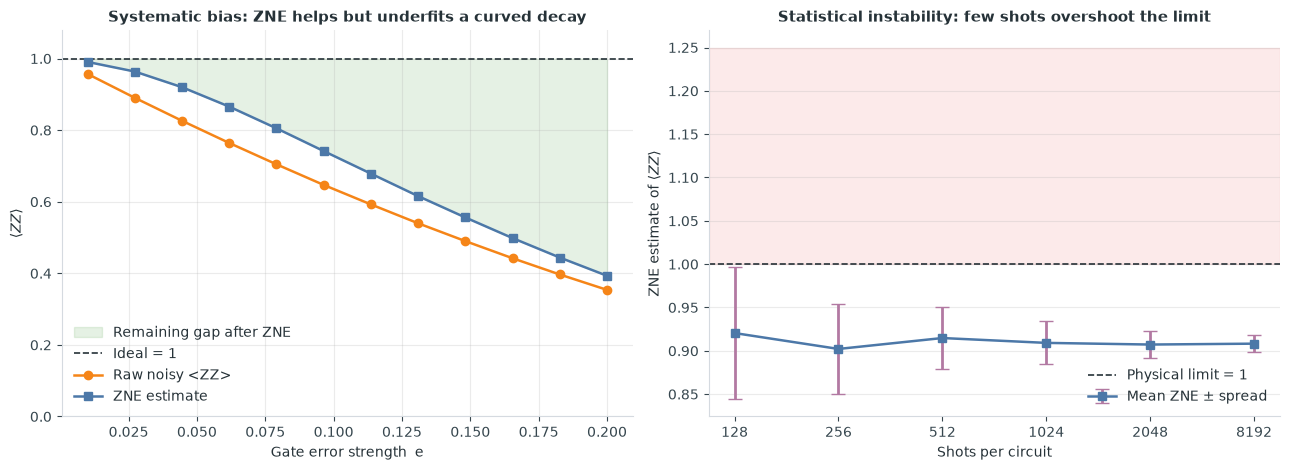

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: systematic bias across noise strengths.
ax1.fill_between(error_strengths, zne_curve, ideal, color="#54A24B", alpha=0.15,
                 label="Remaining gap after ZNE")
ax1.axhline(1.0, color="#263238", linestyle="--", linewidth=1.2, label="Ideal = 1")
ax1.plot(error_strengths, raw_curve, "o-", color="#F58518", linewidth=1.8, label="Raw noisy <ZZ>")
ax1.plot(error_strengths, zne_curve, "s-", color="#4C78A8", linewidth=1.8, label="ZNE estimate")
ax1.set_xlabel("Gate error strength  e")
ax1.set_ylabel(r"$\langle ZZ \rangle$")
ax1.set_title("Systematic bias: ZNE helps but underfits a curved decay", weight="bold", fontsize=11)
ax1.legend(frameon=False, loc="lower left")
ax1.set_ylim(0, 1.08)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(alpha=0.25)

# Right: statistical instability vs shots.
ax2.axhspan(1.0, 1.25, color="#E53935", alpha=0.10)
ax2.axhline(1.0, color="#263238", linestyle="--", linewidth=1.2, label="Physical limit = 1")
ax2.errorbar(range(len(shot_budgets)), means, yerr=spreads, fmt="s-", color="#4C78A8",
             ecolor="#B279A2", elinewidth=2, capsize=5, linewidth=1.8, label="Mean ZNE ± spread")
ax2.set_xticks(range(len(shot_budgets)))
ax2.set_xticklabels(shot_budgets)
ax2.set_xlabel("Shots per circuit")
ax2.set_ylabel(r"ZNE estimate of $\langle ZZ \rangle$")
ax2.set_title("Statistical instability: few shots overshoot the limit", weight="bold", fontsize=11)
ax2.legend(frameon=False, loc="lower right")
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Summary of the Week

The reusable functions built across the week now cover the whole mitigation pipeline, and the saved `results` dictionary holds the key numbers.

- **Jul 6** — `run_circuit` returns $\langle ZZ \rangle$ for any circuit from a single call.
- **Jul 7** — readout mitigation recovers most of the correlation lost to measurement error.
- **Jul 8** — folding produces logically identical circuits at scales `1, 3, 5`, verified against the original unitary.
- **Jul 9** — linear extrapolation gives a zero-noise estimate close to the ideal value.
- **Jul 10** — ZNE beats the raw value across the whole tested range, but it degrades in two ways: a linear fit systematically underestimates the curved decay as the noise grows, and with too few shots the extrapolation scatters enough to cross the physical limit. Both say the same thing — trust the estimate only when the decay is close to linear and the shot budget is large.

In [13]:
print("Saved results")
print("=============")
for key, value in results.items():
    if isinstance(value, float):
        print(f"{key:28s}: {round(value, 6)}")
    else:
        print(f"{key:28s}: {value}")

Saved results
ideal_zz                    : 1.0
readout_raw_zz              : 0.7146
readout_mitigated_zz        : 1.0
scale_factors               : [1, 3, 5]
folding_all_equivalent      : True
zne_estimate                : 0.977661
zne_error_from_ideal        : 0.022339
zne_always_helps_highshots  : True
zne_max_systematic_gap      : 0.606812
zne_overshoot_fraction_128_shots: 0.2
zne_spread_128_shots        : 0.076006
